# What level of energy availability is required for a population to achieve economic and AI competitiveness, and how far are different regions from that threshold?
* How does energy availability per capita influence economic output?
* What level of energy and infrastructure is required to support AI development (compute, data centers, research)?
* Does technology drive energy expansion, or does energy enable technology and AI?
* How far is Africa from leading regions like Europe and United States in:
    * Energy
    * Infrastructure
    * AI capability
* Given realistic growth rates, how long would it take for Africa to close the gap?



In [31]:
# Import Libraries

import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import pycountry_convert as pc


In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mwauandrew/gdp-by-world-region/gdp-world-regions-stacked-area.csv
/kaggle/input/datasets/mwauandrew/ai-publications-stanford-ai-index-2026/PUBLIC DATA_ 2026 AI INDEX REPORT-20260415T101239Z-3-001/PUBLIC DATA_ 2026 AI INDEX REPORT/6. Medicine/Charts/fig_6.4.6.pdf
/kaggle/input/datasets/mwauandrew/ai-publications-stanford-ai-index-2026/PUBLIC DATA_ 2026 AI INDEX REPORT-20260415T101239Z-3-001/PUBLIC DATA_ 2026 AI INDEX REPORT/6. Medicine/Charts/fig_6.2.9.pdf
/kaggle/input/datasets/mwauandrew/ai-publications-stanford-ai-index-2026/PUBLIC DATA_ 2026 AI INDEX REPORT-20260415T101239Z-3-001/PUBLIC DATA_ 2026 AI INDEX REPORT/6. Medicine/Charts/fig_6.1.9.pdf
/kaggle/input/datasets/mwauandrew/ai-publications-stanford-ai-index-2026/PUBLIC DATA_ 2026 AI INDEX REPORT-20260415T101239Z-3-001/PUBLIC DATA_ 2026 AI INDEX REPORT/6. Medicine/Charts/fig_6.2.3.pdf
/kaggle/input/datasets/mwauandrew/ai-publications-stanford-ai-index-2026/PUBLIC DATA_ 2026 AI INDEX REPORT-20260415T101239Z

In [15]:
# Define the file paths
file_paths = {
    "data_center_csv": "/kaggle/input/datasets/rockyt07/data-center-dataset/Book1 (1).csv",
    "data_center_xlsx": "/kaggle/input/datasets/rockyt07/data-center-dataset/Book1.xlsx",
    "urban_population": "/kaggle/input/datasets/mwauandrew/of-population-living-in-urban/share-of-population-urban.csv",
    "electricity_access": "/kaggle/input/datasets/mwauandrew/population-acess-to-electricity/share-of-the-population-with-access-to-electricity.csv",
    "internet_usage": "/kaggle/input/datasets/mwauandrew/internet-penetration-of-population/share-of-individuals-using-the-internet.csv",
    "manufacturing_gdp": "/kaggle/input/datasets/mwauandrew/manufacturing-value-added-of-gdp/manufacturing-value-added-to-gdp.csv",
    "median_age": "/kaggle/input/datasets/mwauandrew/median-age-by-country-and-region/median-age.csv"
}

# Load all files into variables (DataFrames)
data = {}

for name, path in file_paths.items():
    try:
        if not os.path.exists(path):
            print(f"⚠️ File not found: {path}")
            continue
            
        if path.endswith('.csv'):
            data[name] = pd.read_csv(path)
        elif path.endswith('.xlsx'):
            data[name] = pd.read_excel(path)
        else:
            print(f"Unsupported file format: {path}")
            continue
            
        print(f"✅ Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} columns")
        
    except Exception as e:
        print(f"❌ Error loading {name}: {str(e)}")

# Now you can use them like this:
dc_csv = data.get("data_center_csv")
dc_xlsx = data.get("data_center_xlsx")
urban = data.get("urban_population")
electricity = data.get("electricity_access")
internet = data.get("internet_usage")
manufacturing = data.get("manufacturing_gdp")
age = data.get("median_age")

# Quick check
print("\n=== Quick Summary ===")
for name, df in data.items():
    if df is not None:
        print(f"{name}: {df.shape} | Columns: {list(df.columns[:8])}...")  # first 8 columns

✅ Loaded data_center_csv: 191 rows × 21 columns
✅ Loaded data_center_xlsx: 191 rows × 21 columns
✅ Loaded urban_population: 14,950 rows × 4 columns
✅ Loaded electricity_access: 6,912 rows × 4 columns
✅ Loaded internet_usage: 6,331 rows × 4 columns
✅ Loaded manufacturing_gdp: 8,524 rows × 4 columns
✅ Loaded median_age: 38,203 rows × 5 columns

=== Quick Summary ===
data_center_csv: (191, 21) | Columns: ['country', 'total_data_centers', 'hyperscale_data_centers', 'colocation_data_centers', 'floor_space_sqft_total', 'power_capacity_MW_total', 'average_renewable_energy_usage_percent', 'tier_distribution']...
data_center_xlsx: (191, 21) | Columns: ['country', 'total_data_centers', 'hyperscale_data_centers', 'colocation_data_centers', 'floor_space_sqft_total', 'power_capacity_MW_total', 'average_renewable_energy_usage_percent', 'tier_distribution']...
urban_population: (14950, 4) | Columns: ['Entity', 'Code', 'Year', 'Urban population (% of total population)']...
electricity_access: (6912, 4

In [16]:
# Data Centers
dc_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 21 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   country                                       191 non-null    object
 1   total_data_centers                            191 non-null    int64 
 2   hyperscale_data_centers                       191 non-null    object
 3   colocation_data_centers                       191 non-null    object
 4   floor_space_sqft_total                        191 non-null    object
 5   power_capacity_MW_total                       191 non-null    object
 6   average_renewable_energy_usage_percent        191 non-null    object
 7   tier_distribution                             179 non-null    object
 8   key_operators                                 170 non-null    object
 9   cloud_provider                                149 non-null    object
 10  in

In [17]:
## dc_csv into Numeric form
cols_to_clean = [
    "power_capacity_MW_total",
    "internet_penetration_percent",
    "avg_latency_to_global_hubs_ms",
    "number_of_fiber_connections",
    "growth_rate_of_data_centers_percent_per_year",
    "average_renewable_energy_usage_percent"
]

In [18]:
for col in cols_to_clean:
    print(f"\n--- {col} ---")
    print(dc_csv[col].head())


--- power_capacity_MW_total ---
0    ~12,000+
1     ~2,000+
2     ~1,000+
3     ~8,000+
4        ~700
Name: power_capacity_MW_total, dtype: object

--- internet_penetration_percent ---
0    92%
1    92%
2    96%
3    76%
4    91%
Name: internet_penetration_percent, dtype: object

--- avg_latency_to_global_hubs_ms ---
0    40
1    50
2    40
3    75
4    50
Name: avg_latency_to_global_hubs_ms, dtype: object

--- number_of_fiber_connections ---
0    60+
1    30+
2    25+
3    40+
4    20+
Name: number_of_fiber_connections, dtype: object

--- growth_rate_of_data_centers_percent_per_year ---
0    12%
1     8%
2     7%
3    15%
4     6%
Name: growth_rate_of_data_centers_percent_per_year, dtype: object

--- average_renewable_energy_usage_percent ---
0    ~27%
1    40%+
2    0.45
3    0.25
4    40%+
Name: average_renewable_energy_usage_percent, dtype: object


In [19]:
id(df)

134830082290560

In [20]:
print("Before cleaning:")
print(dc_csv[cols_to_clean].head())
print("\nData types before:")
print(dc_csv[cols_to_clean].dtypes)

# ====================== CLEANING STEPS ======================

cols_to_clean = [
    "power_capacity_MW_total",
    "internet_penetration_percent",
    "avg_latency_to_global_hubs_ms",
    "number_of_fiber_connections",
    "growth_rate_of_data_centers_percent_per_year",
    "average_renewable_energy_usage_percent"
]

for col in cols_to_clean:
    if col in dc_csv.columns:
        # Step 1: Convert to string and strip whitespace
        dc_csv[col] = dc_csv[col].astype(str).str.strip()
        
        # Step 2: Remove common unwanted characters (%, commas, etc.)
        dc_csv[col] = dc_csv[col].str.replace(r'[,%\s]', '', regex=True)
        
        # Step 3: Replace common text like "N/A", "unknown", "-" with NaN
        dc_csv[col] = dc_csv[col].replace(['', 'nan', 'N/A', 'Unknown', '-', '—'], np.nan)
        
        # Step 4: Convert to numeric (coerce errors to NaN)
        dc_csv[col] = pd.to_numeric(dc_csv[col], errors='coerce')

print("\n" + "="*60)
print("After cleaning:")
print(dc_csv[cols_to_clean].head(10))
print("\nData types AFTER cleaning:")
print(dc_csv[cols_to_clean].dtypes)

# Summary of cleaning results
print("\n" + "="*60)
print("Cleaning Summary:")
for col in cols_to_clean:
    non_null = dc_csv[col].notna().sum()
    total = len(dc_csv)
    print(f"{col:45} → {non_null:3d}/{total} numeric values ({non_null/total*100:.1f}%)")

Before cleaning:
  power_capacity_MW_total internet_penetration_percent  \
0                ~12,000+                          92%   
1                 ~2,000+                          92%   
2                 ~1,000+                          96%   
3                 ~8,000+                          76%   
4                    ~700                          91%   

  avg_latency_to_global_hubs_ms number_of_fiber_connections  \
0                            40                         60+   
1                            50                         30+   
2                            40                         25+   
3                            75                         40+   
4                            50                         20+   

  growth_rate_of_data_centers_percent_per_year  \
0                                          12%   
1                                           8%   
2                                           7%   
3                                          15%   
4    

In [23]:
col = "average_renewable_energy_usage_percent"

dc_csv[col] = dc_csv[col].apply(
    lambda x: x*100 if pd.notnull(x) and x <= 1 else x
)

In [24]:
def extract_midpoint(val):
    if pd.isna(val):
        return np.nan
    
    val = str(val)
    
    # handle ranges like "100-300"
    if '-' in val:
        parts = val.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan
    
    # remove text like MW
    val = val.replace('MW', '').replace('+', '').strip()
    
    try:
        return float(val)
    except:
        return np.nan

dc_csv["power_capacity_MW_total"] = dc_csv["power_capacity_MW_total"].apply(extract_midpoint)

In [25]:
dc_csv = dc_csv.drop(columns=["number_of_fiber_connections"])

In [26]:
target = "total_data_centers"

features = [
    "power_capacity_MW_total",
    "internet_penetration_percent",
    "avg_latency_to_global_hubs_ms",
    "growth_rate_of_data_centers_percent_per_year",
    "average_renewable_energy_usage_percent"
]

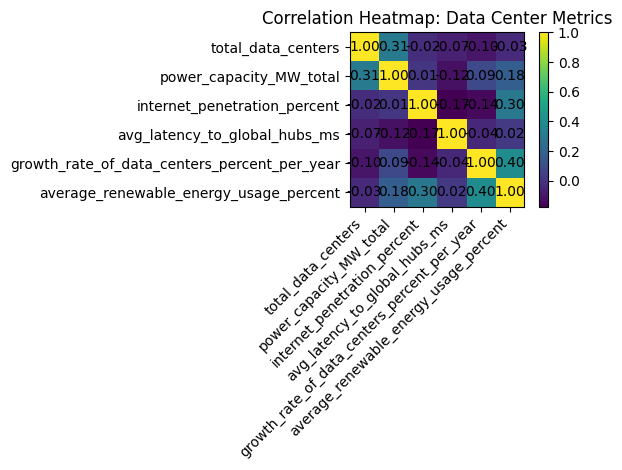

In [27]:
corr_matrix = dc_csv[[target] + features].corr()

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

cax = ax.imshow(corr_matrix, interpolation='nearest')

# Add colorbar
plt.colorbar(cax)

# Set ticks
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values inside cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha='center', va='center')

plt.title("Correlation Heatmap: Data Center Metrics")
plt.tight_layout()

# 🔥 SAVE HERE
plt.savefig('/kaggle/working/correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:

# Compute R² (square of correlation)
r2_values = {}
for col in features:
    r = dc_csv[[target, col]].corr().iloc[0,1]
    r2_values[col] = r ** 2

r2_df = pd.DataFrame(list(r2_values.items()), columns=["feature", "r2"])
print(r2_df)

scaler = MinMaxScaler()

# Normalize features
scaled_features = scaler.fit_transform(dc_csv[features])

scaled_df = pd.DataFrame(scaled_features, columns=features)

# Apply R² weights
for col in features:
    scaled_df[col] = scaled_df[col] * r2_values[col]

# Final impact score per country
dc_csv["impact_score"] = scaled_df.sum(axis=1)

fig = px.choropleth(
    dc_csv,
    locations="country",
    locationmode="country names",
    color="impact_score",
    hover_name="country",
    title="Data Center Infrastructure Impact Score (R² Weighted)",
)

fig.show()

fig.write_html("/kaggle/working/impact_map.html")


                                        feature        r2
0                       power_capacity_MW_total  0.098771
1                  internet_penetration_percent  0.000490
2                 avg_latency_to_global_hubs_ms  0.004238
3  growth_rate_of_data_centers_percent_per_year  0.010775
4        average_renewable_energy_usage_percent  0.000814


In [46]:
fixes = {
    "Albania ": "Albania",
    "Congo, Democratic Republic of the": "Democratic Republic of the Congo",
    "Congo, Republic of the": "Republic of the Congo",
    "Côte d’Ivoire": "Ivory Coast",
    "Korea, North": "North Korea",
    "Korea, South": "South Korea",
    "East Timor": "Timor-Leste"  # <-- correct direction
}

dc_csv['country'] = dc_csv['country'].replace(fixes)

In [49]:
def get_continent(country):
    if country == "Timor-Leste":
        return "AS"  # Asia
    
    try:
        code = pc.country_name_to_country_alpha2(country)
        return pc.country_alpha2_to_continent_code(code)
    except:
        return None

In [50]:
dc_csv[dc_csv['continent'].isna()]['country'].unique()

array(['Timor-Leste'], dtype=object)

In [35]:
missing = dc_csv[dc_csv['continent'].isna()]['country'].unique()
print(len(missing), missing)

7 ['Albania ' 'Congo, Democratic Republic of the' 'Congo, Republic of the'
 'Côte d’Ivoire' 'Korea, North' 'Korea, South' 'Timor-Leste']


In [51]:
dc_csv['continent'].value_counts()

continent
AF    54
AS    45
EU    43
NA    23
OC    13
SA    12
Name: count, dtype: int64

In [52]:
continent_dc = (
    dc_csv
    .groupby('continent')['total_data_centers']
    .sum()
    .sort_values(ascending=False)
)

print(continent_dc)

continent
NA    5989
EU    3266
AS    1406
OC     356
SA     336
AF     237
Name: total_data_centers, dtype: int64


In [55]:
import pandas as pd
import plotly.express as px
import pycountry
import numpy as np

# -----------------------------
# 1. Clean country names
# -----------------------------
dc_csv['country'] = dc_csv['country'].str.strip()

fixes = {
    "Congo, Democratic Republic of the": "Democratic Republic of the Congo",
    "Congo, Republic of the": "Republic of the Congo",
    "Côte d’Ivoire": "Ivory Coast",
    "Korea, North": "North Korea",
    "Korea, South": "South Korea",
    "East Timor": "Timor-Leste"
}

dc_csv['country'] = dc_csv['country'].replace(fixes)

# -----------------------------
# 2. Aggregate per country
# -----------------------------
country_dc = dc_csv.groupby('country')['total_data_centers'].sum().reset_index()

# -----------------------------
# 3. Normalize country names (for map compatibility)
# -----------------------------
def normalize_country(name):
    try:
        return pycountry.countries.lookup(name).name
    except:
        return name

country_dc['country'] = country_dc['country'].apply(normalize_country)

# -----------------------------
# 4. Log transform to fix visual dominance
# -----------------------------
country_dc['log_dc'] = np.log1p(country_dc['total_data_centers'])

# -----------------------------
# 5. Global choropleth (balanced visibility)
# -----------------------------
fig = px.choropleth(
    country_dc,
    locations="country",
    locationmode="country names",
    color="log_dc",
    hover_name="country",
    hover_data={"total_data_centers": True, "log_dc": False},
    color_continuous_scale="Viridis",
    title="Global Data Center Distribution (Log-Scaled for Visibility)"
)

fig.show()

# -----------------------------
# 6. Africa-focused view (raw scale still OK here)
# -----------------------------
africa = dc_csv[dc_csv['continent'] == 'Africa']
africa_dc = africa.groupby('country')['total_data_centers'].sum().reset_index()

fig2 = px.choropleth(
    africa_dc,
    locations="country",
    locationmode="country names",
    color="total_data_centers",
    hover_name="country",
    color_continuous_scale="Reds",
    title="Africa Data Center Distribution"
)

fig.write_html("global_data_centers_map.html")

fig2.show()